<h1>Extracting and Visualizing Stock Data</h1>
<h2>Description</h2>


Extracting essential data from a dataset and displaying it is a necessary part of data science; therefore individuals can make correct decisions based on the data. In this assignment, you will extract some stock data, you will then display this data in a graph.


In [300]:
# %pip install yfinance
# %pip install bs4
# %pip install nbformat
# %pip install matplotlib


In [301]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup


In [302]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)


## Define Graphing Function


In [303]:
# The make_graph function has been modified to use Matplotlib for static graphs. Earlier, it used Plotly to generate interactive dashboards, which caused issues when uploading the notebook in the MARK assignment submission.
import matplotlib.pyplot as plt


def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype(
        "float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date),
                 revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()


## Question 1: Use yfinance to Extract Stock Data


In [304]:
tesla = yf.Ticker('TSLA')


In [305]:
tesla_data = tesla.history(period="max")


In [306]:
tesla_data.reset_index(inplace=True)
tesla_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Question 2: Use Webscraping to Extract Tesla Revenue Data


In [307]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'
html_data = requests.get(url).text


In [308]:
soup = BeautifulSoup(html_data, 'html.parser')


In [309]:
from io import StringIO
tesla_revenue = pd.read_html(StringIO(html_data), attrs={
                             'class': 'historical_data_table'})[1]
tesla_revenue.head()

tesla_revenue.rename(columns={'Tesla Quarterly Revenue (Millions of US $)': 'Date',
                              'Tesla Quarterly Revenue (Millions of US $).1': 'Revenue'}, inplace=True)


In [310]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(
    ',|\$', "", regex=True)


In [311]:
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
tesla_revenue.head()


,Date,Revenue
0,2022-09-30,21454
1,2022-06-30,16934
2,2022-03-31,18756
3,2021-12-31,17719
4,2021-09-30,13757


## Question 3: Use yfinance to Extract Stock Data


In [312]:
gamestop = yf.Ticker("GME")


In [313]:
gme_data = gamestop.history(period="max")


In [314]:
gme_data.reset_index(inplace=True)
gme_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662209,1.603295,1.662209,6892800,0.0,0.0


In [315]:
gme_data['Date'] = gme_data['Date'].dt.tz_localize(None)


## Question 4: Use Webscraping to Extract GME Revenue Data


In [316]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html'
html_data2 = requests.get(url).text


Parse the html data using `beautiful_soup` using parser i.e `html5lib` or `html.parser`.


In [317]:
gme_data = BeautifulSoup(html_data2, 'html.parser')


In [318]:
from io import StringIO
gme_revenue = pd.read_html(StringIO(html_data2), attrs={
                           'class': 'historical_data_table'})[1]
gme_revenue.head()


,GameStop Quarterly Revenue (Millions of US $),GameStop Quarterly Revenue (Millions of US $).1
0,2020-04-30,"$1,021"
1,2020-01-31,"$2,194"
2,2019-10-31,"$1,439"
3,2019-07-31,"$1,286"
4,2019-04-30,"$1,548"


In [319]:
# gme_revenue.dropna(inplace=True)
gme_revenue.rename(columns={'GameStop Quarterly Revenue (Millions of US $)': 'Date',
                   'GameStop Quarterly Revenue (Millions of US $).1': 'Revenue'}, inplace=True)

gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(
    ',|\$', "", regex=True)


Display the last five rows of the `gme_revenue` dataframe using the `tail` function. Take a screenshot of the results.


In [320]:
gme_revenue.tail()


,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Question 5: Plot Tesla Stock Graph


<details><summary>Hint</summary>

```

You just need to invoke the make_graph function with the required parameter to print the graphs.The structure to call the `make_graph` function is `make_graph(tesla_data, tesla_revenue, 'Tesla')`.

```
    
</details>


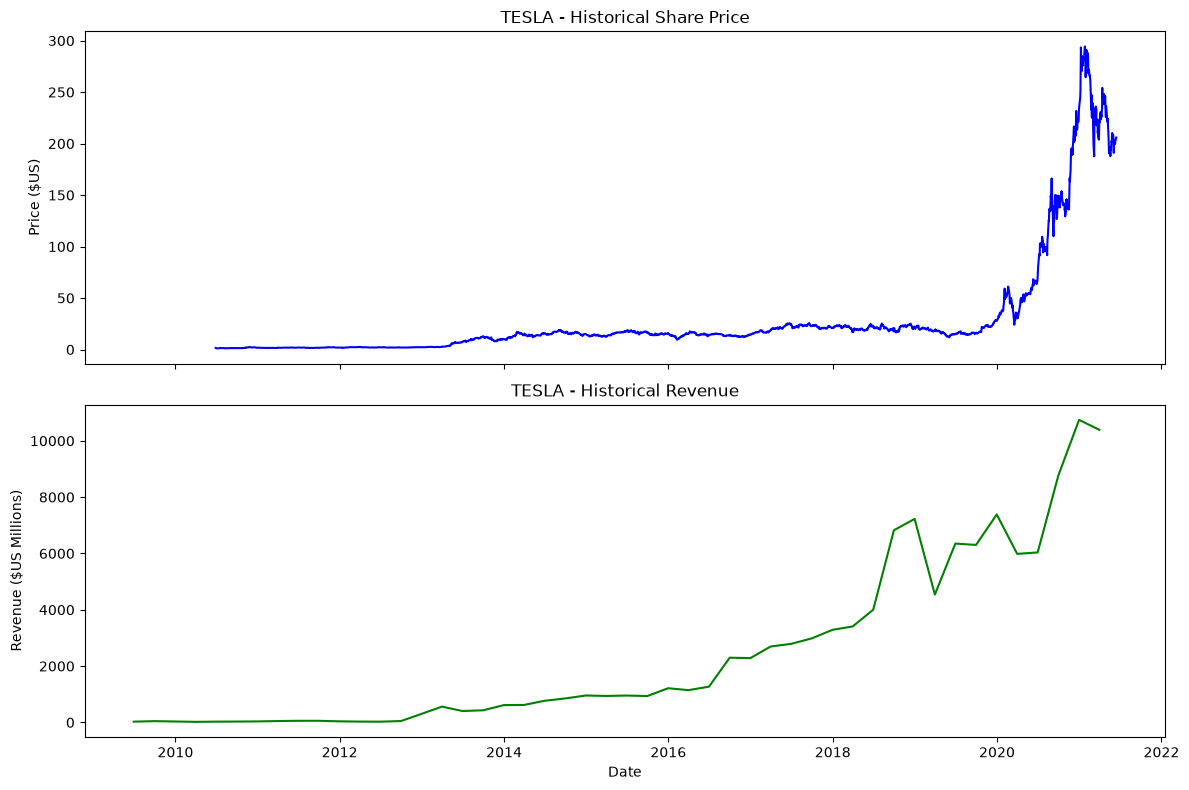

In [321]:
make_graph(tesla_data, tesla_revenue, 'TESLA')


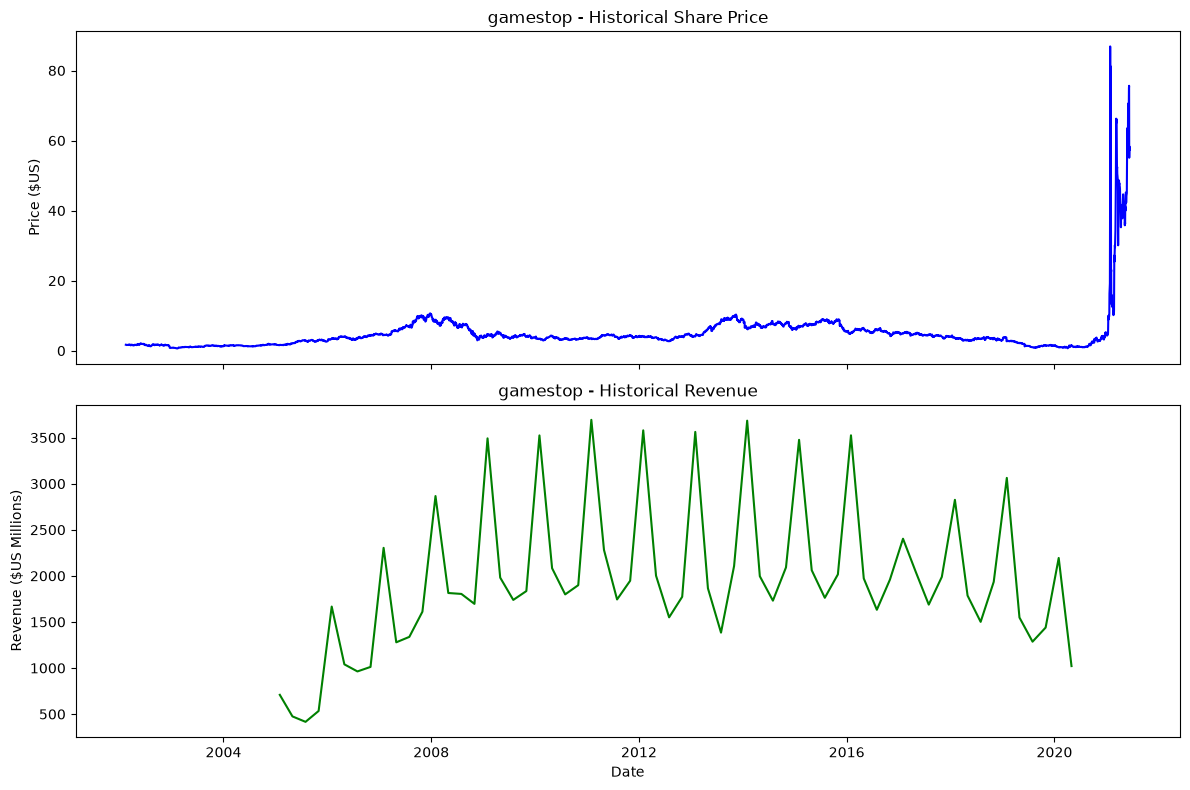

In [325]:
make_graph(gme_data, gme_revenue, 'gamestop')
